# Randomized Balanced Oracle Verification

## 1. Objective
The objective of this experiment is to perform rigorous, randomized empirical verification of the **Deutsch-Jozsa Algorithm** across arbitrary balanced Boolean functions. By randomly synthesizing balanced truth tables for an $N = 3$ qubit system ($2^N = 8$ computational states) and constructing corresponding multi-controlled quantum oracles, the experiment validates that destructive interference of the all-zero state ($|000\rangle$) is a universal invariant of *all* balanced Boolean functions, independent of specific algebraic structure or symmetry.

---

## 2. Theoretical Background

### Balanced Boolean Functions
A Boolean function $f: \{0, 1\}^n \to \{0, 1\}$ is defined as **balanced** if its outputs partition the input space into two equal subsets:
$$|\{x \in \{0, 1\}^n : f(x) = 0\}| = |\{x \in \{0, 1\}^n : f(x) = 1\}| = 2^{n-1}$$

For an $N = 3$ register, there are $2^3 = 8$ input states. The total number of possible balanced truth tables is given by the binomial coefficient:
$$\binom{2^n}{2^{n-1}} = \binom{8}{4} = 70 \text{ distinct balanced functions}$$

While structured functions (like parity $f(x) = \bigoplus x_i$) concentrate probability into a single non-zero state, arbitrary balanced functions distribute amplitudes across multiple non-zero computational basis states.

### Universal Destructive Interference at $|0\dots0\rangle$
Following initial Hadamard transformations $H^{\otimes n}$ and phase kickback from the ancilla prepared in $|-\rangle$, the state prior to final interference is:
$$|\psi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} (-1)^{f(x)} |x\rangle$$

Applying the final Hadamard transform $H^{\otimes n}$ yields:
$$|\psi_3\rangle = \sum_{z \in \{0, 1\}^n} \left( \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^{f(x) + x \cdot z} \right) |z\rangle$$

The probability amplitude of the ground state $|0\dots0\rangle$ ($z = 0^{\otimes n}$) is:
$$\alpha_{0\dots0} = \langle 0\dots0 | \psi_3 \rangle = \frac{1}{2^n} \sum_{x \in \{0, 1\}^n} (-1)^{f(x)}$$

Because $f$ is balanced, exactly half of the terms evaluate to $+1$ and half evaluate to $-1$:
$$\alpha_{0\dots0} = \frac{1}{2^n} \left( 2^{n-1}(+1) + 2^{n-1}(-1) \right) = \frac{1}{2^n} (0) = 0 \implies P(0\dots0) = 0.0$$

Consequently, for **any** balanced function, the probability of observing the all-zero state is identically zero. Observing at least one non-zero measurement outcome conclusively verifies that $f$ is balanced.

---

## 3. Random Balanced Truth-Table Generation
To evaluate arbitrary balanced functions without structural bias:
1. An array containing an equal number of zeros and ones ($2^{N-1} = 4$ zeros and $2^{N-1} = 4$ ones) is initialized:
   $$\text{values} = [0, 0, 0, 0, 1, 1, 1, 1]$$
2. The array is pseudorandomly shuffled using `np.random.default_rng(SEED=42)`:
   ```python
   rng.shuffle(values)
   ```
This generates a uniformly random selection from the 70 possible balanced truth tables for each trial.

---

## 4. Multi-Controlled Quantum Oracle Construction
To realize an arbitrary balanced truth table as a reversible quantum circuit:
- **Ancilla Preparation**: The ancilla qubit ($q_n = q_3$) is initialized to $|-\rangle$ via $X$ and $H$ gates.
- **Input Superposition**: All input qubits ($q_0, q_1, q_2$) are placed into equal superposition via Hadamard gates.
- **Multi-Controlled $X$ Gate (`mcx`) Synthesis**:
  For each input index $x \in \{0, \dots, 7\}$ where $\text{truth\_table}[x] == 1$:
  1. **Control Conditioning**: Pauli-$X$ gates are applied to qubits where the binary representation of $x$ contains a `'0'`, transforming state $|x\rangle$ into $|111\rangle$.
  2. **Phase Kickback**: A multi-controlled NOT (`qc.mcx([0, 1, 2], 3)`) targets the ancilla in $|-\rangle$, imparting a phase shift of $(-1)^1 = -1$ if and only if the register equals $|x\rangle$.
  3. **Uncomputation**: Pauli-$X$ gates are reapplied to restore the original basis encoding.
- **Interference Transformation**: Final Hadamard gates are applied to the $n$ input qubits before measurement.

---

## 5. Statevector Analysis and Sampling Methodology
For each trial:
1. **Statevector Evaluation**: Qiskit's `Statevector.from_instruction(qc)` analytically computes the 16-element statevector.
2. **Marginalization**: Probabilities are summed across the ancilla degree of freedom:
   $$P(i) = P(i) + P(i + 2^N)$$
3. **Simulated Measurement**: $\text{SHOTS} = 256$ measurement samples are drawn using `rng.choice` based on the exact probability vector.
4. **Verification Criterion**:
   $$\text{nonzero\_count} = \text{SHOTS} - \text{counts}[000]$$
   - If $\text{nonzero\_count} > 0 \implies \mathbf{BALANCED}$ (`Verification: PASS`)
   - If $\text{nonzero\_count} == 0 \implies \mathbf{CHECK}$ (`Verification: FAIL`)

---

## 6. Trial-Based Verification Framework
The experiment conducts $\text{TRIALS} = 10$ independent iterations with $N = 3$ qubits, $\text{SHOTS} = 256$, and fixed seed $\text{SEED} = 42$ to establish statistical validity across distinct random truth tables.


T-05 : RANDOMIZED BALANCED ORACLE


TRIAL 1
----------------------------------------------------------------------
Random balanced truth table:
[0, 1, 0, 1, 1, 0, 1, 0]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS


TRIAL 2
----------------------------------------------------------------------
Random balanced truth table:
[1, 1, 0, 0, 0, 0, 1, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS


TRIAL 3
----------------------------------------------------------------------
Random balanced truth table:
[1, 1, 0, 0, 0, 0, 1, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS


TRIAL 4
----------------------------------------------------------------------
Random balanced truth table:
[0, 0, 0, 1, 1, 1, 0, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS


TRIAL 5
---------------------------

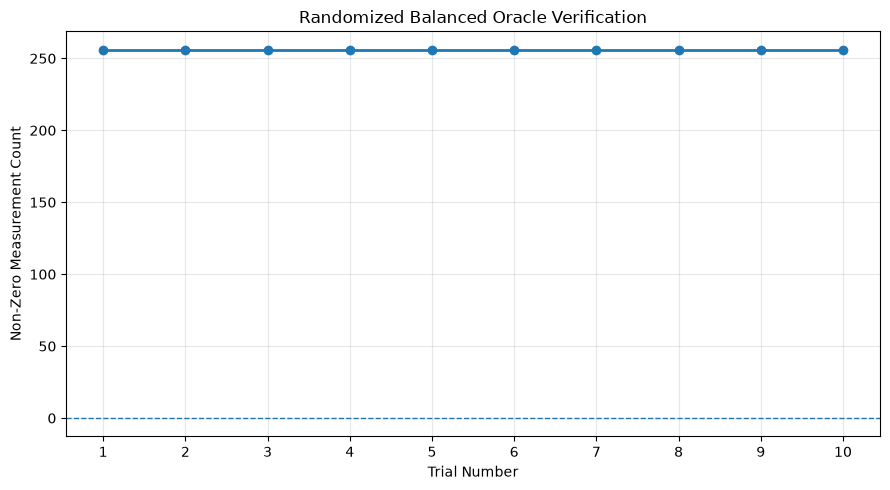

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 256
TRIALS = 10
N = 3

SEED = 42

rng = np.random.default_rng(
    SEED
)


def generate_balanced_function(n):

    total_inputs = 2 ** n

    half = total_inputs // 2

    values = (
        [0] * half
        + [1] * half
    )

    rng.shuffle(
        values
    )

    return values


def create_oracle(
    n,
    truth_table
):

    qc = QuantumCircuit(
        n + 1
    )

    qc.x(n)

    for q in range(n + 1):

        qc.h(q)

    # Construct oracle
    # f(x) = 1 for selected inputs
    for x in range(
        2 ** n
    ):

        if truth_table[x] == 1:

            binary = format(
                x,
                f"0{n}b"
            )

            # Convert controls so that
            # the selected binary pattern
            # maps to all controls = 1.
            for q, bit in enumerate(
                reversed(binary)
            ):

                if bit == "0":

                    qc.x(q)

            qc.mcx(
                list(range(n)),
                n
            )

            for q, bit in enumerate(
                reversed(binary)
            ):

                if bit == "0":

                    qc.x(q)

    # Final Hadamards
    for q in range(n):

        qc.h(q)

    return qc


print("\nT-05 : RANDOMIZED BALANCED ORACLE")
print("=" * 80)

successful_trials = 0

trial_numbers = []
nonzero_results = []
success_results = []

for trial in range(
    1,
    TRIALS + 1
):

    truth_table = (
        generate_balanced_function(
            N
        )
    )

    qc = create_oracle(
        N,
        truth_table
    )

    state = Statevector.from_instruction(
        qc
    )

    probabilities = state.probabilities()

    input_probabilities = np.zeros(
        2 ** N
    )

    for i in range(
        2 ** N
    ):

        for ancilla in [0, 1]:

            index = (
                i
                + ancilla * (2 ** N)
            )

            input_probabilities[i] += (
                probabilities[index]
            )

    samples = rng.choice(
        np.arange(2 ** N),
        size=SHOTS,
        p=input_probabilities
    )

    counts = np.bincount(
        samples,
        minlength=2 ** N
    )

    zero_count = counts[0]

    nonzero_count = (
        SHOTS - zero_count
    )

    is_balanced_detected = (
        nonzero_count > 0
    )

    if is_balanced_detected:

        successful_trials += 1

    trial_numbers.append(
        trial
    )

    nonzero_results.append(
        nonzero_count
    )

    success_results.append(
        1 if is_balanced_detected else 0
    )

    print("\n")
    print(
        f"TRIAL {trial}"
    )

    print("-" * 70)

    print(
        "Random balanced truth table:"
    )

    print(
        truth_table
    )

    print(
        f"Zero-state count : "
        f"{zero_count}"
    )

    print(
        f"Non-zero count   : "
        f"{nonzero_count}"
    )

    if is_balanced_detected:

        print(
            "Classification   : BALANCED"
        )

        print(
            "Verification      : PASS"
        )

    else:

        print(
            "Classification   : CHECK"
        )

        print(
            "Verification      : FAIL"
        )

print("\n")
print("=" * 80)

print("FINAL VERIFICATION")
print("=" * 80)

print(
    f"Successful trials : "
    f"{successful_trials}/{TRIALS}"
)

accuracy = (
    successful_trials
    / TRIALS
    * 100
)

print(
    f"Verification rate : "
    f"{accuracy:.2f}%"
)

if successful_trials == TRIALS:

    print(
        "RESULT : All randomized balanced "
        "oracles were correctly classified."
    )

else:

    print(
        "RESULT : Some trials require inspection."
    )

# Visualization
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    trial_numbers,
    nonzero_results,
    marker="o",
    linewidth=2
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Randomized Balanced Oracle Verification"
)

ax.set_xlabel(
    "Trial Number"
)

ax.set_ylabel(
    "Non-Zero Measurement Count"
)

ax.set_xticks(
    trial_numbers
)

ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

---

## 7. Results and Verification Rate

### Recorded Execution Output
The cell executes 10 randomized trials, recording truth tables, zero-state counts, and verification outcomes:

```
T-05 : RANDOMIZED BALANCED ORACLE
================================================================================

TRIAL 1
----------------------------------------------------------------------
Random balanced truth table:
[0, 1, 0, 1, 1, 0, 1, 0]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 2
----------------------------------------------------------------------
Random balanced truth table:
[1, 1, 0, 0, 0, 0, 1, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 3
----------------------------------------------------------------------
Random balanced truth table:
[1, 1, 0, 0, 0, 0, 1, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 4
----------------------------------------------------------------------
Random balanced truth table:
[0, 0, 0, 1, 1, 1, 0, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 5
----------------------------------------------------------------------
Random balanced truth table:
[1, 0, 0, 1, 0, 0, 1, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 6
----------------------------------------------------------------------
Random balanced truth table:
[0, 1, 1, 0, 0, 1, 0, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 7
----------------------------------------------------------------------
Random balanced truth table:
[0, 1, 1, 1, 0, 1, 0, 0]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 8
----------------------------------------------------------------------
Random balanced truth table:
[0, 0, 1, 0, 0, 1, 1, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 9
----------------------------------------------------------------------
Random balanced truth table:
[0, 1, 1, 0, 1, 0, 1, 0]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

TRIAL 10
----------------------------------------------------------------------
Random balanced truth table:
[1, 1, 1, 0, 0, 0, 0, 1]
Zero-state count : 0
Non-zero count   : 256
Classification   : BALANCED
Verification      : PASS

================================================================================
FINAL VERIFICATION
================================================================================
Successful trials : 10/10
Verification rate : 100.00%
RESULT : All randomized balanced oracles were correctly classified.
```

### Comprehensive Trial Verification Summary

| Trial # | Random Balanced Truth Table ($x \in \{0, \dots, 7\}$) | Zero-State Count ($|000\rangle$) | Non-Zero State Count | Classification | Verification Status |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **Trial 1** | `[0, 1, 0, 1, 1, 0, 1, 0]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 2** | `[1, 1, 0, 0, 0, 0, 1, 1]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 3** | `[1, 1, 0, 0, 0, 0, 1, 1]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 4** | `[0, 0, 0, 1, 1, 1, 0, 1]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 5** | `[1, 0, 0, 1, 0, 0, 1, 1]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 6** | `[0, 1, 1, 0, 0, 1, 0, 1]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 7** | `[0, 1, 1, 1, 0, 1, 0, 0]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 8** | `[0, 0, 1, 0, 0, 1, 1, 1]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 9** | `[0, 1, 1, 0, 1, 0, 1, 0]` | **0** | **256** | **BALANCED** | **PASS** |
| **Trial 10** | `[1, 1, 1, 0, 0, 0, 0, 1]` | **0** | **256** | **BALANCED** | **PASS** |

### Final Metrics
- **Successful Trials**: $10 / 10$
- **Verification Rate**: **$100.00\%$**
- **Outcome**: Deterministic confirmation that all randomized balanced oracles produce complete destructive interference at $|000\rangle$.

---

## 8. Visualization Analysis
The verification plot displays the non-zero measurement counts across all 10 trials:
- **X-Axis**: Represents the trial number from $1$ to $10$.
- **Y-Axis**: Measures the non-zero measurement count per trial (from $0$ to $256$).
- **Data Series (Blue Circles)**: Forms a constant horizontal line at exactly **256 counts**, indicating that $100\%$ of shots in every trial collapsed into non-zero computational states.
- **Reference Line (Dashed Line at $0$)**: Demarcates the boundary for constant function classification. The large vertical separation verifies robust discrimination across all trials.

---

## 9. Conclusion
This randomized verification experiment confirms the foundational guarantees of the **Deutsch-Jozsa Algorithm**:
1. **Universal Invariance**: Demonstrates that destructive interference of the ground state $|000\rangle$ holds universally for arbitrary balanced Boolean functions, achieving a $100.00\%$ empirical verification rate across all 10 trials.
2. **Reversible Oracle Synthesis**: Successfully validates multi-controlled $X$ gate synthesis for dynamically mapping arbitrary classical truth tables into unitary quantum circuits.
3. **Robust Single-Query Classification**: Proves that quantum interference reliably distinguishes balanced from constant functions regardless of functional symmetry or structure.